In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torchvision

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.augmentations import create_simclr_transform

### test

In [3]:
from src.data.augmentations import create_simclr_transform
from src.data.dataset import CIFAR10SimCLR


# ============================================================
# Test SimCLR Dataset
# ============================================================

transform = create_simclr_transform()

dataset = CIFAR10SimCLR(
    root="../data",
    train=True,
    transform=transform,
    download=False,
)

view_1, view_2, label = dataset[0]

print("View 1 shape:", view_1.shape)
print("View 2 shape:", view_2.shape)
print("Label:", label)

View 1 shape: torch.Size([3, 32, 32])
View 2 shape: torch.Size([3, 32, 32])
Label: 6


### test

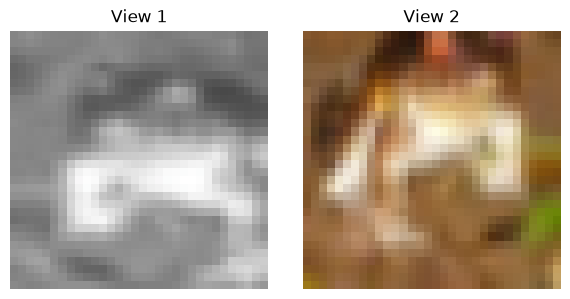

In [4]:
import matplotlib.pyplot as plt
import torch


# ============================================================
# Visualization Helper
# Converts normalized tensors back to displayable images.
# ============================================================

def denormalize(image):
    mean = torch.tensor(
        [0.4914, 0.4822, 0.4465]
    ).view(3, 1, 1)

    std = torch.tensor(
        [0.2470, 0.2435, 0.2616]
    ).view(3, 1, 1)

    image = image * std + mean

    return image.clamp(0, 1)


fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(
    denormalize(view_1).permute(1, 2, 0)
)
axes[0].set_title("View 1")

axes[1].imshow(
    denormalize(view_2).permute(1, 2, 0)
)
axes[1].set_title("View 2")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

### test

In [5]:
from src.data.dataloader import create_dataloader
from src.data.dataset import CIFAR10SimCLR
from src.data.augmentations import create_simclr_transform


# ============================================================
# Test DataLoader
# ============================================================

dataset = CIFAR10SimCLR(
    root="../data",
    train=True,
    transform=create_simclr_transform(),
    download=False,
)


loader = create_dataloader(
    dataset,
    batch_size=32,
)


view_1, view_2, labels = next(iter(loader))


print("View 1 batch:", view_1.shape)
print("View 2 batch:", view_2.shape)
print("Labels:", labels.shape)

View 1 batch: torch.Size([32, 3, 32, 32])
View 2 batch: torch.Size([32, 3, 32, 32])
Labels: torch.Size([32])


In [6]:
import torch

from src.models.resnet_classifier import ResNet18Classifier


# ============================================================
# Test ResNet18 baseline
# ============================================================

model = ResNet18Classifier()

x = torch.randn(4, 3, 32, 32)

output = model(x)

print("Output shape:", output.shape)

Output shape: torch.Size([4, 10])
